# MiniPAR Calibration using Multi-Channel Spec
## Calibrate MiniPAR sensor using AS7341 multi-channel spectral data
This notebook reads multi-channel 'spec' output, performs multi-input linear regression against a reference PAR sensor, inspects coefficients, visualizes fit quality, analyzes channel independence, and validates the calibration.

## Setup: Imports and Helper Functions

In [5]:
import sys
import time
import serial
import glob
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')
from helpers import findDevice, get_par_MP, plot_data_and_fit, get_MP_name, r_squared

# Configuration
BAUD_RATE = 115200


## Device Discovery
Automatically detect MiniPAR, reference sensor, and DC source ports, or specify manually.

In [57]:
# clear ports

PORT_MINIPAR = None
PORT_REF = None


In [59]:
# Try auto-detection
print("Scanning for MiniPAR...")

print("\nScanning for reference sensor (TIA)...")
if not PORT_REF:
    PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
    if(PORT_REF):
        with serial.Serial(PORT_REF) as ser:
            ser.write("\x02\x04".encode())
            ser.flush()
if not PORT_REF:
    print("Reference sensor not found. Set PORT_REF manually in next cell.")

if not PORT_MINIPAR:
    PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
if not PORT_MINIPAR:
    print("MiniPAR not found. Set PORT_MINIPAR manually in next cell.")



print(f"\nPORT_MINIPAR: {PORT_MINIPAR}")
print(f"PORT_REF: {PORT_REF}")


Scanning for MiniPAR...

Scanning for reference sensor (TIA)...
Received message: MiniPAR,1.1, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: MiniPAR,1.1


PORT_MINIPAR: /dev/ttyACM1
PORT_REF: /dev/ttyACM0


In [60]:
# Uncomment and set if auto-detection fails
# PORT_MINIPAR = "/dev/ttyUSB0"
# PORT_DC = "/
# Verify ports are set
assert PORT_MINIPAR, "PORT_MINIPAR not set"
assert PORT_REF, "PORT_REF not set"
print(f"Using MiniPAR at {PORT_MINIPAR}, Reference at {PORT_REF}")

Using MiniPAR at /dev/ttyACM1, Reference at /dev/ttyACM0


## Serial Communication Functions

In [ ]:
def get_spec(port):
    """Request 'spec' from MiniPAR and return list of channel floats."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write("spec_raw\n".encode())
        time.sleep(0.2)
        line = ser.readline().decode(errors='ignore').strip()
    if not line:
        raise RuntimeError(f"No response from {port}")
    
    parts = [p.strip() for p in line.split(',') if p.strip()]
    # Skip device name if present
    try:
        if parts[0] and not parts[0][0].isdigit():
            parts = parts[1:]
    except Exception:
        pass
    
    return np.array([float(x) for x in parts], dtype=float)


def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)




print("Serial functions loaded.")

print(getPAR_TIA(PORT_REF))
print(get_par_MP(PORT_MINIPAR, raw=False))
print(get_spec(PORT_MINIPAR))


Serial functions loaded.
54.437936
7.77
[0.2182 0.3273 0.215  0.0846 0.0475 0.0738 0.2707 0.0776 0.     0.    ]


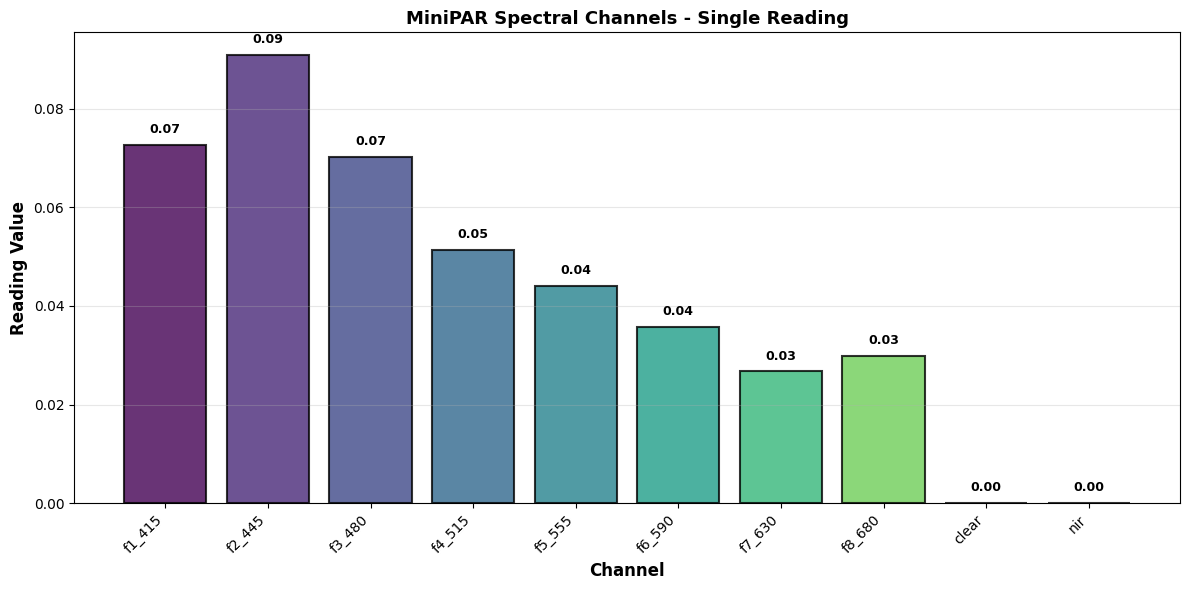


Channel readings:
  f1_415: 0.0727
  f2_445: 0.0909
  f3_480: 0.0701
  f4_515: 0.0513
  f5_555: 0.0441
  f6_590: 0.0357
  f7_630: 0.0267
  f8_680: 0.0299
  clear: 0.0000
  nir: 0.0000

Number of channels: 10


In [19]:
# test reading
single_reading = get_spec(PORT_MINIPAR)

all_channel_names = ["f1_415", "f2_445", "f3_480", "f4_515",
                     "f5_555", "f6_590", "f7_630", "f8_680",
                     "clear",  "nir"]

# Display channel readings on bar graph
fig, ax = plt.subplots(figsize=(12, 6))
channels = np.arange(1, len(single_reading) + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(single_reading)))
bars = ax.bar(channels, single_reading, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, single_reading)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(single_reading)*0.02, 
            f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Reading Value', fontsize=12, fontweight='bold')
ax.set_title('MiniPAR Spectral Channels - Single Reading', fontsize=13, fontweight='bold')
ax.set_xticks(channels)
ax.set_xticklabels(all_channel_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nChannel readings:")
for name, value in zip(all_channel_names, single_reading):
    print(f"  {name}: {value:.4f}")
print(f"\nNumber of channels: {len(single_reading)}")


In [4]:
# collect data manually by changing light and recording PAR from TIA and spec from MiniPAR
csv_path = 'manual_spec_readings.csv'
manual_channel_names = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                         'f5_555', 'f6_590', 'f7_630', 'f8_680',
                         'clear',  'nir']

from IPython.display import clear_output

def load_manual_readings(path):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
        except Exception as e:
            raise RuntimeError(f'Could not read {path}: {e}')
    else:
        df = pd.DataFrame(columns=['timestamp', 'tia_par', 'filter_name'] + manual_channel_names)
    if 'filter_name' not in df.columns:
        df['filter_name'] = ''
    return df

def plot_manual_spectra(df, current_spec=None, current_label=None, skip_last_channels=2):
    channel_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    selected_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    fig, ax = plt.subplots(figsize=(14, 8))
    plotted = False

    if not df.empty:
        norm_df = df[selected_names].div(df[selected_names].sum(axis=1), axis=0)
        colors = plt.cm.plasma(np.linspace(0, 1, len(norm_df)))
        for plot_idx, (row_idx, row) in enumerate(norm_df.iterrows()):
            filter_name = df.loc[row_idx, 'filter_name'] if 'filter_name' in df.columns else ''
            label = f'{df.loc[row_idx, "timestamp"]} / {df.loc[row_idx, "tia_par"]:.2f}'
            if filter_name:
                label += f' / {filter_name}'
            ax.plot(np.arange(1, len(row) + 1), row.values, marker='o', linewidth=1.8, markersize=6,
                    alpha=0.75, color=colors[plot_idx], label=label)
            plotted = True

    if current_spec is not None:
        spec_arr = np.array(current_spec, dtype=float)
        if skip_last_channels > 0:
            spec_arr = spec_arr[:-skip_last_channels]
        if spec_arr.sum() != 0:
            spec_plot = spec_arr / spec_arr.sum()
        else:
            spec_plot = spec_arr
        ax.plot(np.arange(1, len(spec_plot) + 1), spec_plot, marker='o', linewidth=3, markersize=8,
                color='black', label=current_label or 'Current reading')
        plotted = True

    if not plotted:
        print('No spectral data to display yet.')
        return

    ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (Sum=1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Manual Spectral Readings: Saved + Current', fontsize=14, fontweight='bold')
    ax.set_xticks(np.arange(1, len(channel_names) + 1))
    ax.set_xticklabels(channel_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Timestamp / TIA PAR', fontsize=9, title_fontsize=10, loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

def append_manual_reading(path, row):
    row_df = pd.DataFrame([row])
    if not os.path.exists(path):
        row_df.to_csv(path, index=False)
    else:
        row_df.to_csv(path, index=False, header=False, mode='a')

manual_df = load_manual_readings(csv_path)
print('Manual collection ready.')
print(f'Saved readings file: {csv_path}')
plot_manual_spectra(manual_df)

while True:
    user_input = input('Press Enter to capture next reading, or type esc + Enter to exit: ').strip().lower()
    if user_input in {'esc', 'exit', 'quit'}:
        print('Exiting manual collection loop.')
        break

    try:
        tia_value = getPAR_TIA(PORT_REF)
        spec_values = get_spec(PORT_MINIPAR)
    except Exception as e:
        print(f'Read error: {e}')
        continue

    clear_output(wait=True)
    print(f'TIA PAR reading: {tia_value:.6f}')
    plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}')

    filter_name = input('Enter filter name to save this reading (leave blank to reject): ').strip()
    if not filter_name:
        print('No filter name entered; reading rejected.')
        plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}')
        continue

    new_row = {'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'), 'tia_par': float(tia_value), 'filter_name': filter_name}
    new_row.update({name: float(val) for name, val in zip(manual_channel_names, spec_values)})
    append_manual_reading(csv_path, new_row)
    manual_df = pd.concat([manual_df, pd.DataFrame([new_row])], ignore_index=True)
    clear_output(wait=True)
    print(f'Reading saved to {csv_path}')
    plot_manual_spectra(manual_df)


NameError: name 'os' is not defined

In [6]:
# Preview saved manual spec readings
def preview_manual_readings(path='manual_spec_readings.csv', n=10):
    if not os.path.exists(path):
        print(f'No manual readings file found at {path}')
        return None
    df = pd.read_csv(path)
    if df.empty:
        print(f'{path} is empty')
        return df
    print(f'Preview first {n} rows from {path} (total rows: {len(df)})')
    print(df.head(n).to_string(index=False))
    return df

# Call the helper to preview the CSV contents
preview_manual_readings()


Preview first 10 rows from manual_spec_readings.csv (total rows: 265)
          timestamp   tia_par filter_name  f1_415  f2_445  f3_480  f4_515  f5_555  f6_590  f7_630  f8_680   clear    nir
2026-06-01T13:31:09 99.524550       white  1221.0  3474.0  5192.0  6385.0  6670.0  7211.0  8892.0  5603.0 21428.0 1445.0
2026-06-01T13:31:26 99.327130       white  1220.0  3466.0  5183.0  6374.0  6664.0  7200.0  8875.0  5590.0 21390.0 1443.0
2026-06-01T13:32:15 48.145056        e002   676.0  1912.0  2443.0  1653.0  1327.0  3291.0  6918.0  4610.0 11168.0  858.0
2026-06-01T13:32:50 72.921720        e003   951.0  2742.0  3957.0  4539.0  4438.0  4992.0  6668.0  4835.0 16023.0 1093.0
2026-06-01T13:33:28 61.446480        e004   684.0  1523.0  2283.0  3090.0  3912.0  5576.0  7704.0  4857.0 14138.0 1088.0
2026-06-01T13:34:01 81.534328        e007   860.0  2011.0  3823.0  5563.0  5964.0  6486.0  7979.0  5027.0 17989.0 1278.0
2026-06-01T13:34:39 39.557130        e008   416.0   677.0   753.0   887.0  1722.0  

,timestamp,tia_par,filter_name,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
0,2026-06-01T13:31:09,99.524550,white,1221.0,3474.0,5192.0,6385.0,6670.0,7211.0,8892.0,5603.0,21428.0,1445.0
1,2026-06-01T13:31:26,99.327130,white,1220.0,3466.0,5183.0,6374.0,6664.0,7200.0,8875.0,5590.0,21390.0,1443.0
2,2026-06-01T13:32:15,48.145056,e002,676.0,1912.0,2443.0,1653.0,1327.0,3291.0,6918.0,4610.0,11168.0,858.0
3,2026-06-01T13:32:50,72.921720,e003,951.0,2742.0,3957.0,4539.0,4438.0,4992.0,6668.0,4835.0,16023.0,1093.0
4,2026-06-01T13:33:28,61.446480,e004,684.0,1523.0,2283.0,3090.0,3912.0,5576.0,7704.0,4857.0,14138.0,1088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,2026-06-02T13:09:50,27.785748,e795,427.0,1047.0,1206.0,531.0,339.0,1422.0,5437.0,4046.0,7198.0,615.0
261,2026-06-02T13:10:21,17.272940,e797,365.0,1116.0,892.0,245.0,205.0,499.0,2496.0,3581.0,4867.0,403.0
262,2026-06-02T13:10:57,16.384532,e798,412.0,1497.0,1308.0,359.0,211.0,313.0,1096.0,3096.0,4425.0,323.0
263,2026-06-02T13:11:43,5.057354,e799,163.0,697.0,445.0,73.0,58.0,64.0,180.0,719.0,1531.0,131.0


## Data Collection
Collect spectral data and reference PAR values across multiple current levels.

## Linear Regression: Multiple Input Channels

Loaded 265 manual readings from manual_spec_readings.csv for regression.
LINEAR REGRESSION RESULTS

Matrix rank: 10 / 9
Residual norm: 34.1956

Fit Quality:
  R²: 0.99972682
  RMSE: 0.35922126

Coefficients:
  Channel 1: 0.0078557421
  Channel 2: 0.0034384705
  Channel 3: 0.002848948
  Channel 4: 0.0028951318
  Channel 5: 0.0024648412
  Channel 6: 0.0023016114
  Channel 7: 0.002563504
  Channel 8: 0.00085216413
  Channel 9: -0.00073911312
  Intercept:  -0.34167195


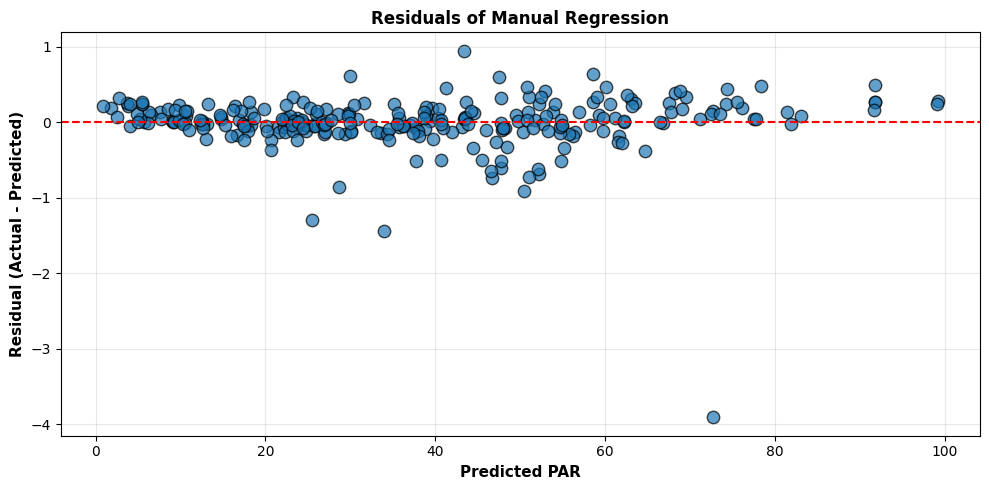

In [37]:
def load_manual_regression(path='manual_spec_readings.csv', channel_names=None):
    df = load_manual_readings(path)
    if df.empty:
        raise ValueError(f"No manual regression data found in {path}")
    if channel_names is None:
        channel_names = manual_channel_names
    missing = [c for c in channel_names if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected spectral columns in {path}: {missing}")
    X = df[channel_names].astype(float).to_numpy()
    y = df['tia_par'].astype(float).to_numpy()
    return X, y, df


X, y, df = load_manual_regression(csv_path, manual_channel_names)
X = X[:, 0:9]  # Use only the first 8 channels for regression

X_manual = X

y_manual = y
print(f"Loaded {X_manual.shape[0]} manual readings from {csv_path} for regression.")

def compute_coeffs(X, y):
    """Fit multi-input linear regression: y ≈ X @ c + intercept"""
    A = np.hstack([X, np.ones((X.shape[0], 1))])  # [ch1, ch2, ..., 1]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    return coeffs, residuals, rank, s


def r_squared(y_true, y_pred):
    """Calculate R² fit quality."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot


# Perform regression
coeffs, residuals, rank, s = compute_coeffs(X, y)
intercept = coeffs[-1]
channels_coeffs = coeffs[:-1]

y_pred = (X @ channels_coeffs) + intercept
r2 = r_squared(y, y_pred)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nMatrix rank: {rank} / {X.shape[1]}")
print(f"Residual norm: {np.linalg.norm(residuals):.6g}")
print(f"\nFit Quality:")
print(f"  R²: {r2:.8g}")
print(f"  RMSE: {rmse:.8g}")
print(f"\nCoefficients:")
for i, c in enumerate(channels_coeffs, start=1):
    print(f"  Channel {i}: {c:.8g}")
print(f"  Intercept:  {intercept:.8g}")
print("=" * 60)

# Residual plot
residuals = y - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, residuals, s=80, alpha=0.7, edgecolors='k', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted PAR', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title('Residuals of Manual Regression', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
# Display fit coefficients, 95% relative SEs and parameter covariance
import numpy as np
import pandas as pd
from math import sqrt
try:
    from scipy import stats
    t_crit = stats.t.ppf(0.975, df=max(1, X.shape[0] - (X.shape[1] + 1)))
except Exception:
    # fallback approximate 95% critical value
    t_crit = 1.96
# Reconstruct design matrix used in regression (X currently is used for regression)
A = np.hstack([X, np.ones((X.shape[0], 1))])
n, p = A.shape
# Residuals and sigma^2 estimate
resid = (y - y_pred) if 'y' in globals() else (y_manual - y_pred)
SSR = float(np.sum(resid**2))
dof = max(1, n - p)
sigma2 = SSR / dof
# Covariance matrix of parameters
try:
    ATA_inv = np.linalg.inv(A.T.dot(A))
except np.linalg.LinAlgError:
    ATA_inv = np.linalg.pinv(A.T.dot(A))
cov_matrix = sigma2 * ATA_inv
# coefficients vector (including intercept)
params = np.concatenate([channels_coeffs, np.array([intercept])])
param_names = [f'ch{i+1}' for i in range(len(channels_coeffs))] + ['intercept']
se = np.sqrt(np.abs(np.diag(cov_matrix)))
# relative standard error expressed using 95% CI half-width divided by coef magnitude (in %).
rel_se_pct = np.full_like(se, np.nan, dtype=float)
for i, (coef, s_e) in enumerate(zip(params, se)):
    if abs(coef) > 0:
        rel_se_pct[i] = (t_crit * s_e / abs(coef)) * 100.0
# Build DataFrame for display
df_params = pd.DataFrame({
    'param': param_names,
    'coef': params,
    'std_err': se,
    '95ci_halfwidth': t_crit * se,
    'rel_se_pct_95': rel_se_pct
})
# display nicely
print('Fit parameters and 95% relative standard errors (percent):')
display(df_params[['param','coef','std_err','95ci_halfwidth','rel_se_pct_95']])

print('Correlation coefficients between parameters:')
diag = np.sqrt(np.abs(np.diag(cov_matrix)))
outer = np.outer(diag, diag)
with np.errstate(divide='ignore', invalid='ignore'):
    corr_matrix = cov_matrix / outer
corr_matrix[outer == 0] = np.nan
corr_df = pd.DataFrame(corr_matrix, index=param_names, columns=param_names)
display(corr_df.round(6))


Fit parameters and 95% relative standard errors (percent):


,param,coef,std_err,95ci_halfwidth,rel_se_pct_95
0,ch1,0.007189,0.001191,0.002334,32.470174
1,ch2,0.003100,0.000352,0.000690,22.252223
2,ch3,0.002453,0.000206,0.000404,16.487647
3,ch4,0.002547,0.000156,0.000305,11.981138
4,ch5,0.002136,0.000138,0.000271,12.695725
5,ch6,0.001998,0.000106,0.000208,10.432124
6,ch7,0.002238,0.000064,0.000126,5.638334
7,ch8,0.000477,0.000055,0.000107,22.524047
8,intercept,-0.525976,0.060716,0.119004,22.625384


Correlation coefficients between parameters:


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,intercept
ch1,1.000000,-0.852264,0.218204,-0.324716,0.023189,-0.166713,-0.300485,-0.438308,0.359949
ch2,-0.852264,1.000000,-0.679422,0.640778,-0.252250,0.269509,0.219001,0.312816,-0.366871
ch3,0.218204,-0.679422,1.000000,-0.863431,0.573887,-0.389800,0.117756,-0.091187,0.183835
ch4,-0.324716,0.640778,-0.863431,1.000000,-0.843384,0.645436,-0.260393,0.286075,-0.315800
ch5,0.023189,-0.252250,0.573887,-0.843384,1.000000,-0.859504,0.555193,-0.254347,0.192206
ch6,-0.166713,0.269509,-0.389800,0.645436,-0.859504,1.000000,-0.745347,0.457084,-0.148402
ch7,-0.300485,0.219001,0.117756,-0.260393,0.555193,-0.745347,1.000000,-0.544794,-0.000257
ch8,-0.438308,0.312816,-0.091187,0.286075,-0.254347,0.457084,-0.544794,1.000000,-0.460304
intercept,0.359949,-0.366871,0.183835,-0.315800,0.192206,-0.148402,-0.000257,-0.460304,1.000000


In [9]:
# Display top manual regression outliers by absolute fit error
outlier_df = df.copy()
outlier_df['predicted_par'] = y_pred
outlier_df['residual'] = y - y_pred
outlier_df['abs_error'] = np.abs(outlier_df['residual'])
outlier_df['filter_name'] = outlier_df.get('filter_name', '').fillna('').astype(str)
outlier_df = outlier_df.sort_values('abs_error', ascending=False)
print(f'Loaded {len(outlier_df)} manual readings, showing top outliers by fit error:')
display(outlier_df[['timestamp', 'filter_name', 'tia_par', 'predicted_par', 'residual', 'abs_error']].head(10))


Loaded 265 manual readings, showing top outliers by fit error:


,timestamp,filter_name,tia_par,predicted_par,residual,abs_error
178,2026-06-01T16:09:01,e503,68.775824,72.655698,-3.879874,3.879874
110,2026-06-01T15:06:47,e194,32.474560,33.882161,-1.407601,1.407601
130,2026-06-01T15:22:23,e219,24.182766,25.514040,-1.331274,1.331274
69,2026-06-01T14:29:28,e136,44.319976,43.349245,0.970731,0.970731
200,2026-06-01T16:56:11,e708,49.502347,50.448924,-0.946578,0.946578
212,2026-06-01T17:07:15,e720,27.835102,28.654332,-0.819230,0.819230
238,2026-06-02T12:56:38,e749,50.316716,50.992541,-0.675825,0.675825
104,2026-06-01T15:02:20,e188,45.948724,46.611038,-0.662314,0.662314
181,2026-06-01T16:12:20,e506,59.176104,58.531615,0.644489,0.644489
107,2026-06-01T15:04:18,e191,51.575296,52.217715,-0.642419,0.642419


In [21]:
# Greedy removal of influential manual regression datapoints
fraction_to_remove = 0.90  # Adjust this fraction to inspect the most influential points
n_total = X_manual.shape[0]
num_remove = max(1, int(np.ceil(n_total * fraction_to_remove)))
print(f'Greedy removal selected {num_remove} points ({fraction_to_remove*100:.1f}% of {n_total}) as most influential for coefficient estimation.')

X_full = X_manual
y_full = y_manual
full_coeffs, _, _, _ = compute_coeffs(X_full, y_full)
remaining_indices = list(range(n_total))
removed_indices = []
selected_changes = []

for remove_step in range(num_remove):
    best_idx = None
    best_change = -np.inf
    for idx in remaining_indices:
        candidate = [i for i in remaining_indices if i != idx]
        X_tmp = X_full[candidate]
        y_tmp = y_full[candidate]
        coeffs_tmp, _, _, _ = compute_coeffs(X_tmp, y_tmp)
        change = np.linalg.norm(coeffs_tmp - full_coeffs)
        if change > best_change:
            best_change = change
            best_idx = idx
    removed_indices.append(best_idx)
    selected_changes.append(best_change)
    remaining_indices.remove(best_idx)
    print(f'  Removed point {best_idx} with coefficient-change impact {best_change:.6g}')

X_reduced = X_full[remaining_indices]
y_reduced = y_full[remaining_indices]
coeffs_reduced, _, _, _ = compute_coeffs(X_reduced, y_reduced)
intercept_reduced = coeffs_reduced[-1]
channels_coeffs_reduced = coeffs_reduced[:-1]

y_pred_full = X_full.dot(channels_coeffs_reduced) + intercept_reduced
r2_full = r_squared(y_full, y_pred_full)
rmse_full = np.sqrt(np.mean((y_full - y_pred_full) ** 2))

print('\nRegression on reduced dataset (removed most influential points) evaluated against the whole dataset:')
print(f'  Remaining points: {len(remaining_indices)}')
print(f'  R² (whole dataset): {r2_full:.6f}')
print(f'  RMSE (whole dataset): {rmse_full:.6g}')

removed_df = df.iloc[removed_indices].copy()
removed_df['selected_order'] = np.arange(1, len(removed_indices) + 1)
removed_df['coeff_change'] = selected_changes
removed_df['predicted_full'] = X_full[removed_indices].dot(full_coeffs[:-1]) + full_coeffs[-1]
removed_df['residual_full'] = removed_df['tia_par'] - removed_df['predicted_full']

print('\nMost influential points removed by greedy selection:')
display(removed_df[['selected_order', 'timestamp', 'filter_name', 'tia_par', 'coeff_change', 'residual_full']])

# Optionally show the remaining data fit quality as well
y_pred_reduced = X_reduced.dot(channels_coeffs_reduced) + intercept_reduced
r2_reduced = r_squared(y_reduced, y_pred_reduced)
rmse_reduced = np.sqrt(np.mean((y_reduced - y_pred_reduced) ** 2))
print(f'\nReduced dataset fit quality: R² = {r2_reduced:.6f}, RMSE = {rmse_reduced:.6g}')


Greedy removal selected 239 points (90.0% of 265) as most influential for coefficient estimation.
  Removed point 178 with coefficient-change impact 0.0362701
  Removed point 231 with coefficient-change impact 0.0498279
  Removed point 8 with coefficient-change impact 0.060483
  Removed point 223 with coefficient-change impact 0.0698518
  Removed point 222 with coefficient-change impact 0.0793657
  Removed point 218 with coefficient-change impact 0.0895961
  Removed point 235 with coefficient-change impact 0.0996821
  Removed point 187 with coefficient-change impact 0.109588
  Removed point 191 with coefficient-change impact 0.119407
  Removed point 176 with coefficient-change impact 0.128921
  Removed point 205 with coefficient-change impact 0.138015
  Removed point 40 with coefficient-change impact 0.146677
  Removed point 214 with coefficient-change impact 0.156008
  Removed point 242 with coefficient-change impact 0.164365
  Removed point 11 with coefficient-change impact 0.172397


,selected_order,timestamp,filter_name,tia_par,coeff_change,residual_full
178,1,2026-06-01T16:09:01,e503,68.775824,0.036270,-3.879874
231,2,2026-06-02T12:51:50,e740,3.033762,0.049828,0.406058
8,3,2026-06-01T13:36:03,e010,64.358476,0.060483,-0.392186
223,4,2026-06-02T12:46:27,white5,5.723658,0.069852,0.402453
222,5,2026-06-02T12:46:19,e727,5.723658,0.079366,0.378735
...,...,...,...,...,...,...
243,235,2026-06-02T12:59:43,e768,43.801740,7.072714,-0.019546
46,236,2026-06-01T14:08:14,e106,14.854502,7.311988,0.047394
50,237,2026-06-01T14:11:17,e110,52.488376,7.655952,0.236096
150,238,2026-06-01T15:38:46,e279,78.869110,7.904439,0.506101



Reduced dataset fit quality: R² = 0.999987, RMSE = 0.0879903


In [25]:
# DFBETAS selection: identify the most influential points for each fit parameter

def compute_dfbetas(X, y):
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    coeffs_full, _, _, _ = compute_coeffs(X, y)
    n, p = A.shape
    y_pred_full = A.dot(coeffs_full)
    ss_res = np.sum((y - y_pred_full) ** 2)
    sigma2 = ss_res / max(1, n - p)
    cov = np.linalg.pinv(A.T.dot(A)) * sigma2
    se_full = np.sqrt(np.abs(np.diag(cov)))
    dfbetas = np.zeros((n, p))
    for i in range(n):
        X_i = np.delete(X, i, axis=0)
        y_i = np.delete(y, i)
        coeffs_i, _, _, _ = compute_coeffs(X_i, y_i)
        dfbetas[i] = (coeffs_i - coeffs_full) / np.where(se_full == 0, 1e-12, se_full)
    return dfbetas, coeffs_full, se_full

param_names = [f'ch{i+1}' for i in range(X_full.shape[1])] + ['intercept']
dfbetas, full_coeffs, se_full = compute_dfbetas(X_full, y_full)

# Select the most important points for each parameter
TOP_N_PER_PARAM = 4
selected_indices = set()
for j, name in enumerate(param_names):
    order = np.argsort(np.abs(dfbetas[:, j]))[::-1]
    top_indices = order[:TOP_N_PER_PARAM]
    selected_indices.update(top_indices.tolist())
    print(f"Top {TOP_N_PER_PARAM} points for {name}: {top_indices.tolist()}\n  DFBETAS = {np.round(np.abs(dfbetas[top_indices, j]), 4).tolist()}\n")

selected_indices = sorted(selected_indices)
print(f"Unique selected indices across all parameters: {selected_indices} (count={len(selected_indices)})")

# Refit using only the selected influential points and evaluate on the original dataset
X_selected = X_full[selected_indices]
y_selected = y_full[selected_indices]
coeffs_selected, _, _, _ = compute_coeffs(X_selected, y_selected)
intercept_selected = coeffs_selected[-1]
channels_coeffs_selected = coeffs_selected[:-1]

y_pred_selected = X_full.dot(channels_coeffs_selected) + intercept_selected
r2_selected = r_squared(y_full, y_pred_selected)
rmse_selected = np.sqrt(np.mean((y_full - y_pred_selected) ** 2))

print('\nDFBETAS-selected regression evaluated against the original full dataset:')
print(f'  Selected point count: {len(selected_indices)}')
print(f'  R²: {r2_selected:.6f}')
print(f'  RMSE: {rmse_selected:.6g}')
print(f'  Selected coefficients: {np.round(coeffs_selected, 6).tolist()}')

if 'r2' in globals() and 'rmse' in globals():
    print(f'  Full-model R²: {r2:.6f}, RMSE: {rmse:.6g}')

# Display most influential points with details
print("\n" + "=" * 80)
print("MOST INFLUENTIAL POINTS SUMMARY")
print("=" * 80)

influence_summary = []
for idx in selected_indices:
    filter_name = df.iloc[idx].get('filter_name', '') if 'filter_name' in df.columns else ''
    par_intensity = df.iloc[idx]['tia_par'] if 'tia_par' in df.columns else y_full[idx]
    
    # Get the top influential parameters for this point
    abs_dfbetas = np.abs(dfbetas[idx])
    top_param_idx = np.argsort(abs_dfbetas)[::-1][:3]  # Top 3 influenced parameters
    influences = [(param_names[p_idx], abs_dfbetas[p_idx]) for p_idx in top_param_idx]
    
    influence_summary.append({
        'index': idx,
        'filter_name': filter_name,
        'par_intensity': par_intensity,
        'influences': influences
    })

for item in influence_summary:
    print(f"\nPoint {item['index']}:")
    print(f"  Filter Name: {item['filter_name']}")
    print(f"  PAR Intensity: {item['par_intensity']:.6f}")
    print(f"  Most Influences (top DFBETAS):")
    for param_name, dfbetas_val in item['influences']:
        print(f"    - {param_name}: {dfbetas_val:.4f}")

print("\n" + "=" * 80)


Top 4 points for ch1: [178, 208, 8, 130]
  DFBETAS = [0.2487, 0.2429, 0.2419, 0.2387]

Top 4 points for ch2: [130, 8, 208, 110]
  DFBETAS = [0.6611, 0.3882, 0.2312, 0.1793]

Top 4 points for ch3: [130, 8, 40, 59]
  DFBETAS = [0.748, 0.4594, 0.1705, 0.1493]

Top 4 points for ch4: [8, 130, 40, 178]
  DFBETAS = [0.4657, 0.3371, 0.2002, 0.1537]

Top 4 points for ch5: [178, 8, 90, 228]
  DFBETAS = [0.2933, 0.275, 0.1885, 0.1515]

Top 4 points for ch6: [178, 8, 90, 231]
  DFBETAS = [0.3609, 0.2147, 0.13, 0.1131]

Top 4 points for ch7: [130, 110, 2, 69]
  DFBETAS = [0.4318, 0.2466, 0.2138, 0.1513]

Top 4 points for ch8: [130, 110, 8, 169]
  DFBETAS = [0.4662, 0.3085, 0.1913, 0.1548]

Top 4 points for intercept: [178, 231, 8, 212]
  DFBETAS = [0.5973, 0.2126, 0.156, 0.1474]

Unique selected indices across all parameters: [2, 8, 40, 59, 69, 90, 110, 130, 169, 178, 208, 212, 228, 231] (count=14)

DFBETAS-selected regression evaluated against the original full dataset:
  Selected point count: 14


## Analysis: Channel Independence (SVD)

## Visualization: Fit Quality and Channel Analysis

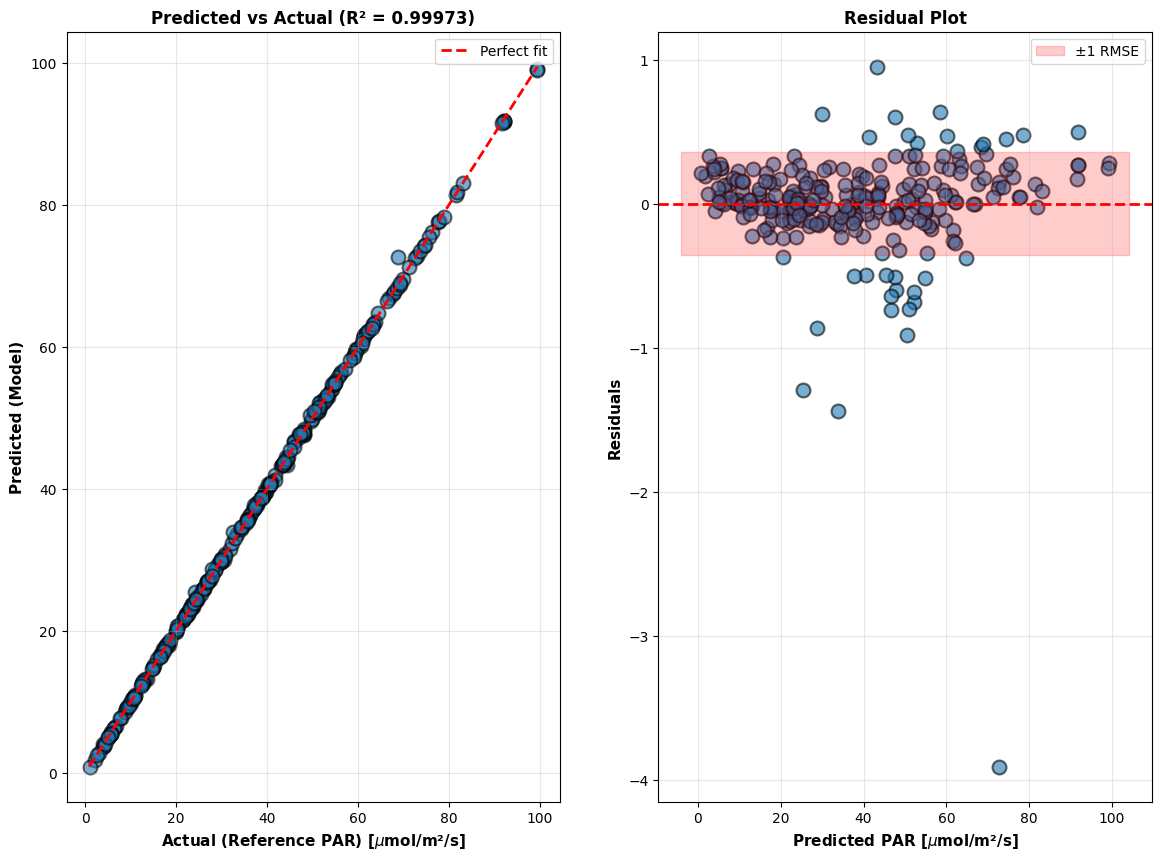

Plots saved to calibration_fit_analysis.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual using manually collected data
ax = axes[0]
ax.scatter(y_manual, y_pred, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
lims = [np.min([y_manual.min(), y_pred.min()]), np.max([y_manual.max(), y_pred.max()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit')
ax.set_xlabel('Actual (Reference PAR) [$\u00B5$mol/m²/s]', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted (Model)', fontsize=11, fontweight='bold')
ax.set_title(f'Predicted vs Actual (R² = {r2:.5f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Residuals for manually collected data
ax = axes[1]
residuals_data = y_manual - y_pred
ax.scatter(y_pred, residuals_data, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.fill_between(ax.get_xlim(), -rmse, rmse, alpha=0.2, color='red', label=f'±1 RMSE')
ax.set_xlabel('Predicted PAR [$\u00B5$mol/m²/s]', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

#plt.tight_layout()
plt.savefig('calibration_fit_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plots saved to calibration_fit_analysis.png")

## Coefficient Inspection & Approval
**Review the coefficients below before uploading.** Adjust if needed.

In [107]:
# Display coefficients for inspection
print("\n" + "=" * 60)
print("CALIBRATION COEFFICIENTS FOR UPLOAD")
print("=" * 60)
coeffs_display = coeffs.copy()
print(f"\nCommand format: cal_par_coeffs,<c1>,<c2>,...,<intercept>")
print(f"\nFull coefficient array (including intercept):")
print(coeffs_display)

# CSV format for upload
coeffs_csv = ",".join([f"{c:.6g}" for c in coeffs_display])
print(f"\nCSV format for upload:")
print(coeffs_csv)

# Save to JSON for later use
coeffs_data = {
    'coeffs': coeffs_display.tolist(),
    'channel_coeffs': channels_coeffs.tolist(),
    'intercept': float(intercept),
    'r2': float(r2),
    'rmse': float(rmse),
    'condition_number': float(cond_number),
    'timestamp': None  # Will be filled if uploaded
}

with open('calibration_coeffs.json', 'w') as f:
    json.dump(coeffs_data, f, indent=2)
print(f"\nCoefficients saved to calibration_coeffs.json")
print("=" * 60)


CALIBRATION COEFFICIENTS FOR UPLOAD

Command format: cal_par_coeffs,<c1>,<c2>,...,<intercept>

Full coefficient array (including intercept):
[ 7.18936226e-03  3.09967221e-03  2.45317143e-03  2.54672379e-03
  2.13550011e-03  1.99841881e-03  2.23817584e-03  4.76634533e-04
 -5.25975882e-01]

CSV format for upload:
0.00718936,0.00309967,0.00245317,0.00254672,0.0021355,0.00199842,0.00223818,0.000476635,-0.525976

Coefficients saved to calibration_coeffs.json


## Upload Coefficients
**Run this cell only after reviewing the coefficients above.**

In [ ]:
# CONFIRM UPLOAD
CONFIRM_UPLOAD = False  # Set to True to enable upload

def upload_coeffs(port, coeffs):
    """Upload coefficients to MiniPAR."""
    vals = ",".join([f"{c:.6g}" for c in coeffs])
    cmd = f"cal_par_coeffs,{vals}\n"
    print(f"Sending: {cmd.strip()}")
    
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write(cmd.encode())
        time.sleep(0.2)
        resp = ser.readline().decode(errors='ignore').strip()
    return resp

if CONFIRM_UPLOAD:
    print(f"Uploading coefficients to {PORT_MINIPAR}...")
    try:
        response = upload_coeffs(PORT_MINIPAR, coeffs)
        print(f"Upload response: {response}")
        print("✓ Coefficients uploaded successfully!")
    except Exception as e:
        print(f"✗ Upload failed: {e}")
else:
    print("Upload disabled. Set CONFIRM_UPLOAD = True to proceed.")

## Post-Validation: Verify Calibration
Compare MiniPAR 'par' readings against reference sensor at several current levels.

In [ ]:
# Wait for user to run post-validation
print("\nPost-validation requires running the calibrated device.")
print("Ensure coefficients have been uploaded and device rebooted if needed.\n")

# Test currents (subset of calibration range)
test_currents = [0.3, 0.7, 1.2]
validation_data = []

print("Running validation sweep...\n")
print(f"{'Current (A)':<15} {'Reference (PAR)':<20} {'MiniPAR (PAR)':<20} {'Error (abs)':<15} {'Error (%)':<15}")
print("-" * 85)

for I in test_currents:
    if PORT_DC:
        set_current(PORT_DC, I)
    time.sleep(1.0)
    
    try:
        ref = getPAR_TIA(PORT_REF)
        par = get_par(PORT_MINIPAR)
        error_abs = abs(par - ref)
        error_pct = (error_abs / ref * 100) if ref != 0 else 0
        
        validation_data.append({
            'current': I,
            'ref': ref,
            'par': par,
            'error_abs': error_abs,
            'error_pct': error_pct
        })
        
        print(f"{I:<15.2f} {ref:<20.4f} {par:<20.4f} {error_abs:<15.4f} {error_pct:<15.2f}%")
    except Exception as e:
        print(f"{I:<15.2f} ERROR: {e}")

if validation_data:
    errors_abs = [d['error_abs'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    print("-" * 85)
    print(f"{'Mean error':<15} {np.mean([d['ref'] for d in validation_data]):<20.4f} {np.mean([d['par'] for d in validation_data]):<20.4f} {np.mean(errors_abs):<15.4f} {np.mean(errors_pct):<15.2f}%")
    print("\nValidation complete.")
else:
    print("No validation data collected.")

## Validation Summary

In [ ]:
if validation_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Reference vs Calibrated PAR
    ax = axes[0]
    refs = [d['ref'] for d in validation_data]
    pars = [d['par'] for d in validation_data]
    ax.scatter(refs, pars, s=150, alpha=0.7, edgecolors='k', linewidth=2)
    lims = [min(refs + pars), max(refs + pars)]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
    ax.set_xlabel('Reference Sensor PAR', fontsize=11, fontweight='bold')
    ax.set_ylabel('MiniPAR (Calibrated) PAR', fontsize=11, fontweight='bold')
    ax.set_title('Post-Validation: MiniPAR vs Reference', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot 2: Validation Errors
    ax = axes[1]
    currents_val = [d['current'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    colors = ['green' if e < 5 else 'orange' if e < 10 else 'red' for e in errors_pct]
    ax.bar(range(len(currents_val)), errors_pct, color=colors, alpha=0.7, edgecolor='k', linewidth=1.5)
    ax.axhline(y=5, color='green', linestyle='--', lw=1.5, label='5% threshold')
    ax.axhline(y=10, color='orange', linestyle='--', lw=1.5, label='10% threshold')
    ax.set_xticks(range(len(currents_val)))
    ax.set_xticklabels([f"{c:.1f}A" for c in currents_val])
    ax.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Current', fontsize=11, fontweight='bold')
    ax.set_title('Validation Errors by Current Level', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('validation_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Validation plot saved to validation_results.png")
else:
    print("No validation data to plot.")